# Logistic Regression

This notebook explores the intuition behind Logistic Regression using the Perceptron Trick, sigmoid function, and decision boundary visualization.
The goal is to understand how linear classifiers work mathematically and visually before implementing Logistic Regression using scikit-learn.

In [42]:
from sklearn.datasets import make_classification
import numpy as np
X,y =make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=30)

In [43]:
import matplotlib.pyplot as plt

# Visualizing the Dataset

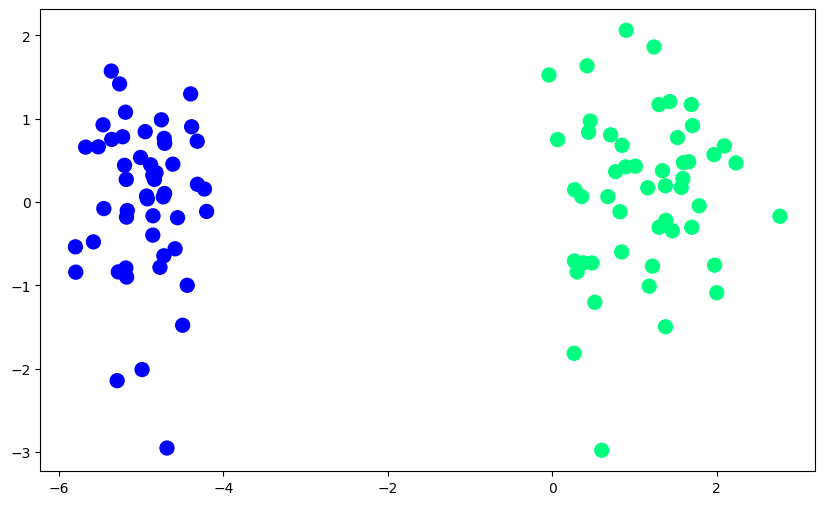

In [44]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.show()

# Implementing the Perceptron Trick

In [45]:
def perceptron(X,y):
    X=np.insert(X,0,1,axis=1)
    weights=np.ones(X.shape[1])
    lr=0.1
    for i in range(1000):
        j=np.random.randint(0,100)
        y_hat=step(np.dot(X[j],weights))
        weights=weights+lr*(y[j]-y_hat)*X[j]
    return  weights[0],weights[1:]

In [46]:
def step(z):
    return 1 if z>0 else 0

In [47]:
intercept_,coef_=perceptron(X,y)

In [48]:
print(coef_)
print(intercept_)

[1.1204053  0.40381514]
1.2000000000000002


In [49]:
m=-(coef_[0]/coef_[1])
b=-(intercept_/coef_[1])

In [50]:
x_input=np.linspace(-3,3,100)
y_input=m*x_input+b

(-3.0, 2.0)

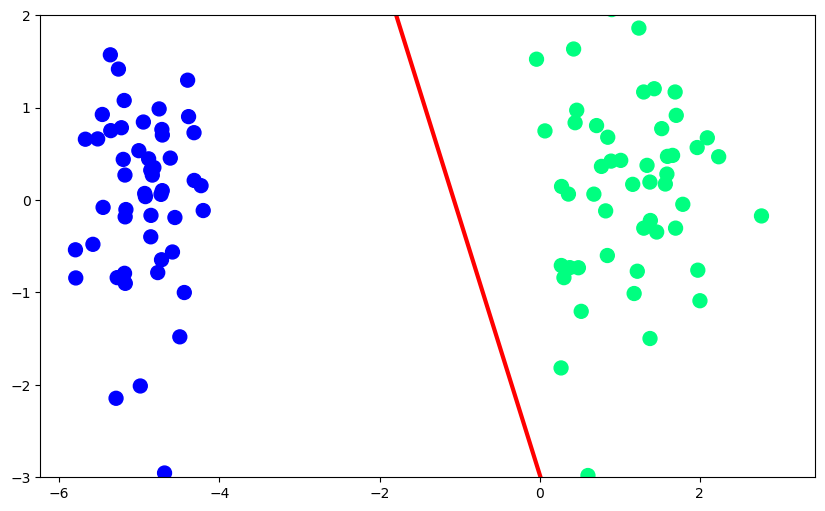

In [51]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

# Understanding the Sigmoid Function

In [52]:
def perceptron(X,y):
    
    X=np.insert(X,0,1,axis=1)
    weights=np.ones(X.shape[1])
    lr = 0.1 
    for i in range(1000):
        j=np.random.randint(0,100)
        y_hat=sigmoid(np.dot(X[j],weights))
        weights=weights+lr*(y[j]-y_hat)*X[j]
        
    return weights[0],weights[1:]

In [53]:
def sigmoid(z):
    return 1/(1 + np.exp(-z))

In [54]:
intercept_,coef_ = perceptron(X,y)

In [55]:
m=-(coef_[0]/coef_[1])
b=-(intercept_/coef_[1])

In [56]:
x_input1=np.linspace(-3,3,100)
y_input1=m*x_input+b

(-3.0, 2.0)

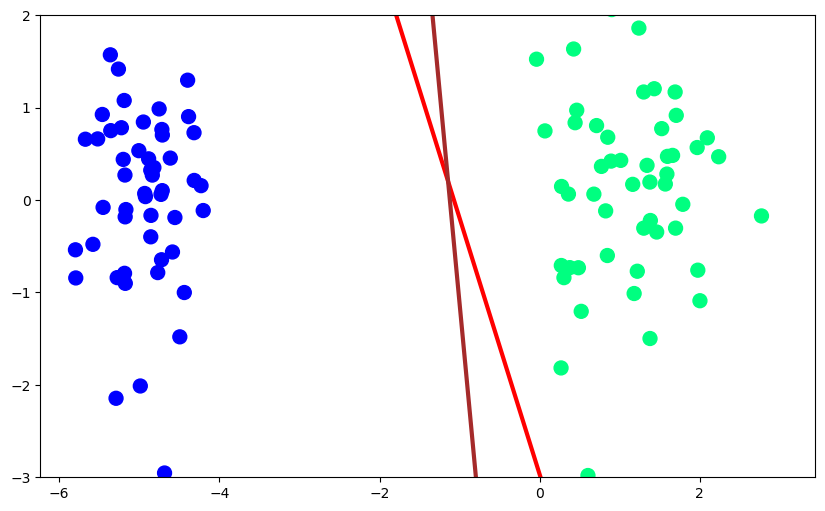

In [57]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input1,y_input1,color='brown',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

In [58]:
from sklearn.linear_model import LogisticRegression
lor=LogisticRegression()
lor.fit(X,y)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [59]:
m=-(lor.coef_[0][0]/lor.coef_[0][1])
b=-(lor.intercept_/lor.coef_[0][1])

In [60]:
x_input2=np.linspace(-3,3,100)
y_input2=m*x_input2+b

(-3.0, 2.0)

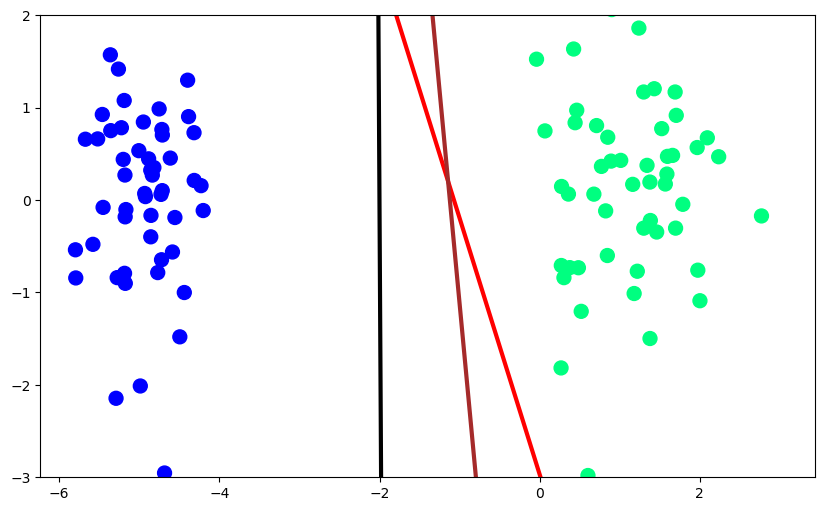

In [61]:
plt.figure(figsize=(10,6))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.plot(x_input2,y_input2,color='black',linewidth=3)
plt.plot(x_input1,y_input1,color='brown',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)